In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Read file, keep only the two needed columns
df = pd.read_csv("data/spam.csv", encoding="latin-1")[["v1", "v2"]]
df.columns = ["label", "message"]
print(df.head())

# 2. Class distribution (before encoding)
counts = df["label"].value_counts()
total = len(df)
print(f"Ham:  {counts['ham']} messages ({counts['ham'] / total * 100:.1f}%)")
print(f"Spam: {counts['spam']} messages ({counts['spam'] / total * 100:.1f}%)")
print(f"Total: {total} messages")

# Encode labels: ham -> 0, spam -> 1
df["label"] = df["label"].replace({"ham": 0, "spam": 1}).astype(int)

# 3. Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    df["message"], df["label"], test_size=0.2, random_state=42
)

# 4. Bag of Words (fit on train only, then transform both)
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 5. Train, predict, evaluate
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Ham:  4825 messages (86.6%)
Spam: 747 messages (13.4%)
Total: 5572 messages
Accuracy: 0.9776
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.84      0.91       150

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



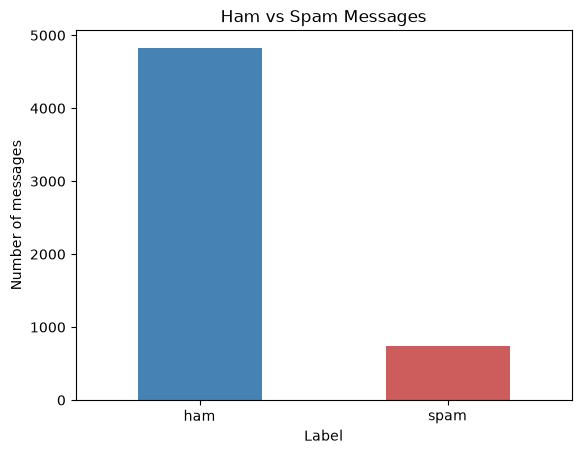

In [4]:
import matplotlib.pyplot as plt

counts.plot(kind="bar", color=["steelblue", "indianred"])
plt.title("Ham vs Spam Messages")
plt.xlabel("Label")
plt.ylabel("Number of messages")
plt.xticks(rotation=0)
plt.show()